In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
url = "https://raw.githubusercontent.com/tirthajyoti/Machine-Learning-with-Python/master/Datasets/Mall_Customers.csv"
df = pd.read_csv(url)
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [6]:
df.drop(columns=['CustomerID'], inplace=True)

In [7]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


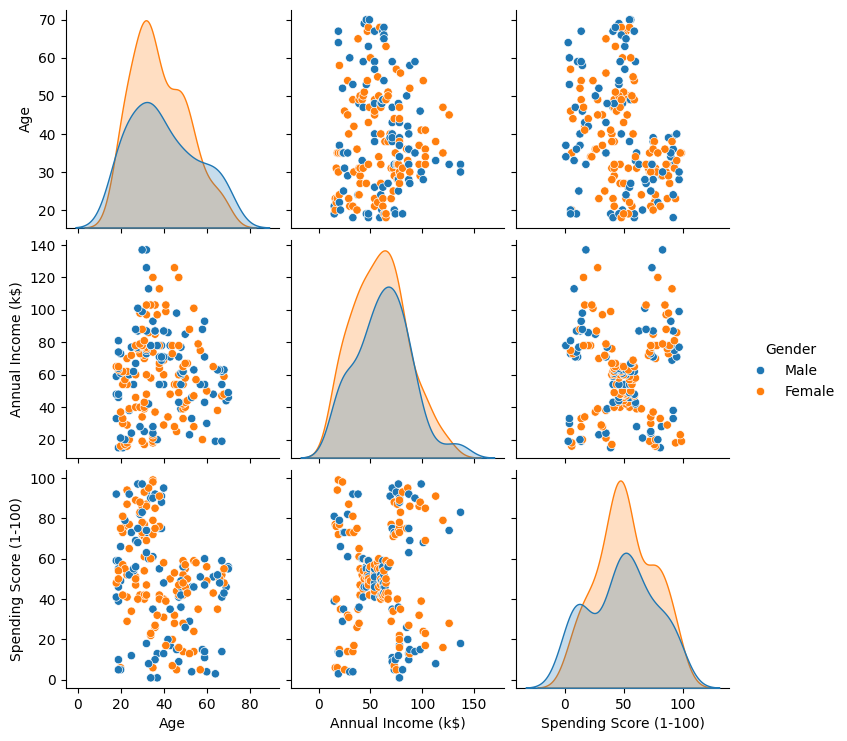

In [9]:
sns.pairplot(df, hue='Gender')
plt.show()

In [13]:
df.drop(columns=['Gender'],inplace=True)
df.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.datasets import make_moons

In [14]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

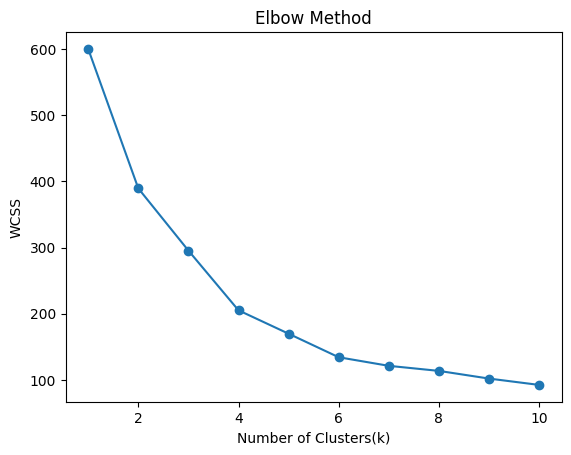

In [15]:
wcss = []

for k in range(1,11):
  kmeans = KMeans(n_clusters=k, random_state=42)
  kmeans.fit(X_scaled)
  wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters(k)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

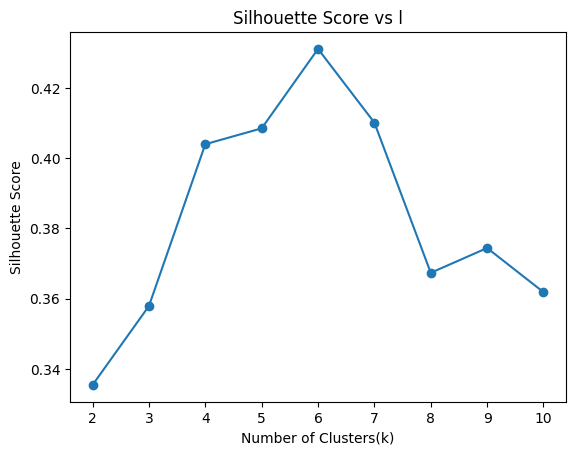

In [20]:
silscore = []

for k in range(2,11):
  kmeans = KMeans(n_clusters=k, random_state=42)
  labels = kmeans.fit_predict(X_scaled)
  score = silhouette_score(X_scaled, labels)
  silscore.append(score)

plt.plot(range(2,11), silscore, marker='o')
plt.xlabel("Number of Clusters(k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs l")
plt.show()

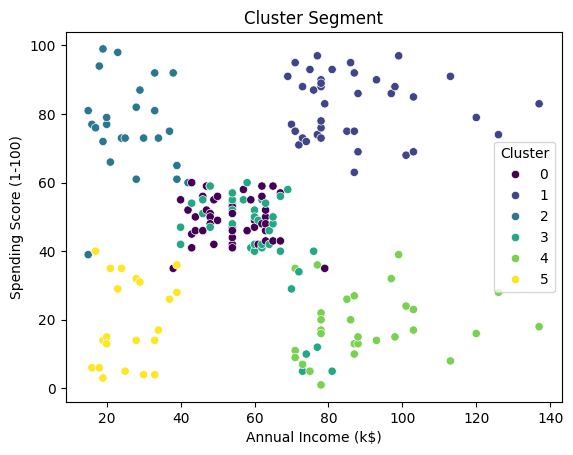

In [21]:
kmeans = KMeans(n_clusters=6, random_state=42)

df['Cluster'] = kmeans.fit_predict(X_scaled)

sns.scatterplot(x=df['Annual Income (k$)'], y=df['Spending Score (1-100)'], hue=df['Cluster'], palette='viridis')
plt.title("Cluster Segment")
plt.show()

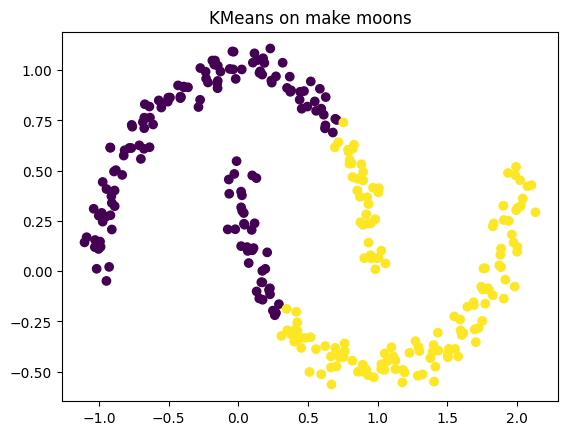

In [25]:
X_moons,_ = make_moons(n_samples=300, noise=0.05, random_state=42)
kmeans = KMeans(n_clusters=2, random_state=42)
labels = kmeans.fit_predict(X_moons)

plt.scatter(X_moons[:,0], X_moons[:,1], c=labels)
plt.title("KMeans on make moons")
plt.show()

##Problem 2 - DBSCAN

In [26]:
from sklearn.cluster import DBSCAN

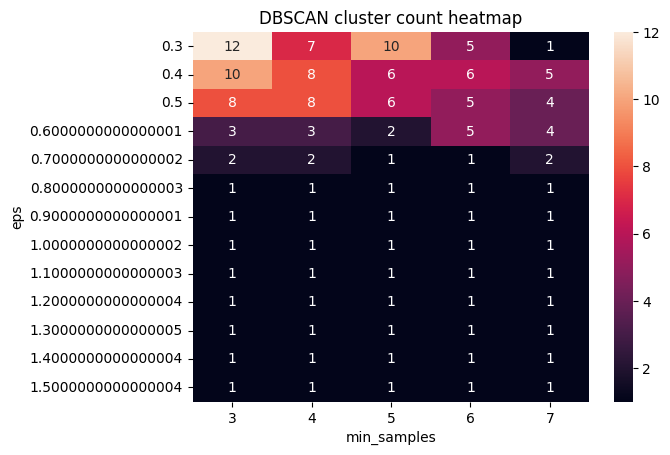

In [29]:
eps_values = np.arange(0.3,1.6,0.1)
min_samples_values = range(3,8)
results=[]

for eps in eps_values:
  for min_samples in min_samples_values:
    db = DBSCAN(eps=eps, min_samples=min_samples)
    labels = db.fit_predict(X_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    results.append([eps,min_samples,n_clusters])

res_df = pd.DataFrame(results, columns=['eps','min_samples','clusters'])
pivot = res_df.pivot(index='eps', columns='min_samples',values='clusters')

sns.heatmap(pivot, annot=True, fmt='d')
plt.title('DBSCAN cluster count heatmap')
plt.show()


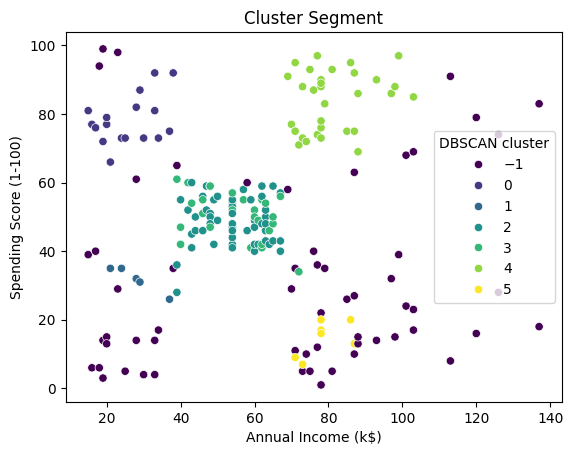

In [30]:
db = DBSCAN(eps=0.5, min_samples=5)
df['DBSCAN cluster'] = db.fit_predict(X_scaled)

sns.scatterplot(x=df['Annual Income (k$)'], y=df['Spending Score (1-100)'], hue=df['DBSCAN cluster'], palette='viridis')
plt.title("Cluster Segment")
plt.show()

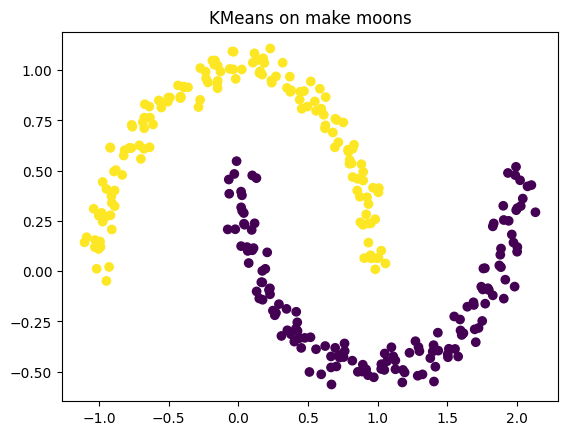

In [34]:
db = DBSCAN(eps=0.2, min_samples=5)
labels = db.fit_predict(X_moons)

plt.scatter(X_moons[:,0], X_moons[:,1], c=labels)
plt.title("KMeans on make moons")
plt.show()

##Problem 3 - Decision Trees and Ensemble

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score

In [36]:
X, y = make_moons(n_samples=10000, random_state=42, noise=0.5)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

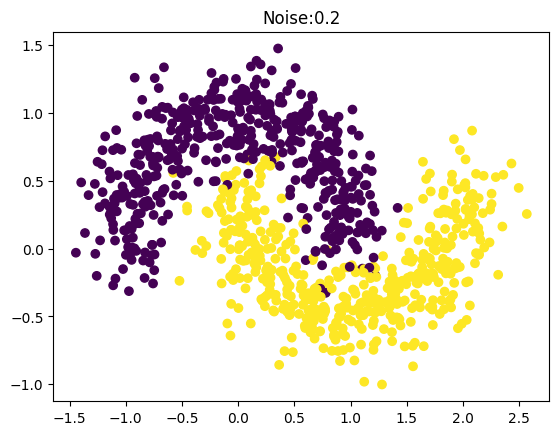

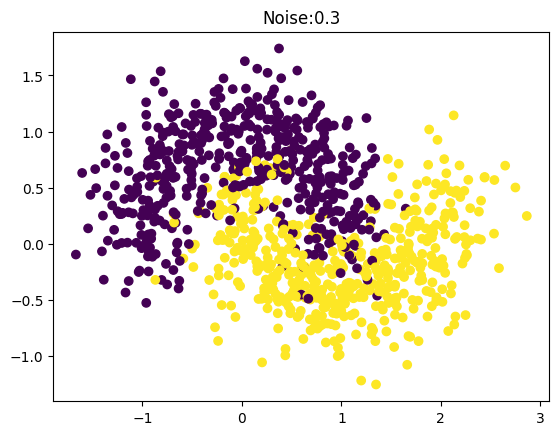

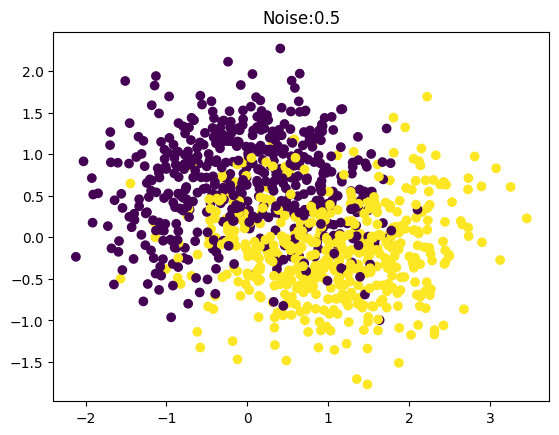

In [38]:
for noise in [0.2,0.3,0.5]:
  X_temp,y_temp = make_moons(n_samples=1000, random_state=42, noise=noise)

  plt.scatter(X_temp[:,0], X_temp[:,1], c=y_temp)
  plt.title(f"Noise:{noise}")
  plt.show()

In [42]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train,y_train)
y_pred_dt = dt.predict(X_test)
dt_acc = accuracy_score(y_test,y_pred_dt)
print(f"Accuracy : {dt_acc*100:.2f}%")

Accuracy : 74.60%


In [43]:
rf = RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(X_train,y_train)
y_pred_rf = rf.predict(X_test)
rf_acc = accuracy_score(y_test,y_pred_rf)
print(f"Accuracy : {rf_acc*100 :.2f}%")

Accuracy : 80.30%


In [44]:
ada = AdaBoostClassifier(n_estimators=100, random_state=42)
ada.fit(X_train,y_train)
y_pred_ada = ada.predict(X_test)
ada_acc = accuracy_score(y_test,y_pred_ada)
print(f"Accuracy : {ada_acc*100 :.2f}%")

Accuracy : 82.05%
